In [ ]:
import matplotlib.pyplot
import pandas as pd
import numpy as np
import pickle

try:
    df = pd.read_pickle('/content/XrayNeumonia.pkl')
    print("Successfully read with pd.read_pickle.")
except Exception as e_pd:
    print(f"Error reading 'XrayNeumonia.pkl' with pandas: {e_pd}")
    print("Attempting to read with standard pickle module...")
    try:
        with open('/content/XrayNeumonia.pkl', 'rb') as f:
            data = pickle.load(f)
        if isinstance(data, pd.DataFrame):
            df = data
            print("Successfully read with standard pickle and identified as DataFrame.")
        else:
            df = pd.DataFrame(data)
            print("Successfully read with standard pickle and converted to DataFrame.")
    except Exception as e_pkl:
        print(f"Error reading 'XrayNeumonia.pkl' with standard pickle: {e_pkl}")
        print("It appears the pickle file might be corrupted, truncated, or not in an expected format.")
        print("Please ensure the file is complete, not damaged, and is a valid pickled pandas DataFrame.")
        df = None

Successfully read with pd.read_pickle.


In [ ]:
df.head()

,Matriz,label
0,"[[42, 153, 24, 165, 81, 73, 86, 99, 106, 113, ...",1
1,"[[2, 2, 1, 1, 1, 1, 58, 123, 2, 8, 11, 14, 16,...",1
2,"[[64, 64, 63, 62, 62, 78, 140, 76, 59, 59, 58,...",1
3,"[[0, 0, 2, 3, 5, 9, 13, 18, 22, 26, 33, 39, 45...",1
4,"[[0, 0, 0, 0, 0, 0, 31, 125, 53, 11, 18, 20, 2...",1


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import numpy as np

X = np.array(df['Matriz'].tolist())
y = df['label'] # La columna objetivo

X = X.reshape(X.shape[0], -1)


# 2. Inicializar el modelo
# 'n_neighbors' es el hiperparámetro K
knn = KNeighborsClassifier(n_neighbors=5)

# 3. Entrenar el modelo
knn.fit(X, y)


KNeighborsClassifier()

In [ ]:
# 4. Predecir una nueva imagen
new_image_sample = X[0:1] # Take the first sample, keeping it as a 2D array (1 sample, n_features)

# Make prediction
prediction = knn.predict(new_image_sample)

print(f"The predicted label for the new image is: {prediction[0]}")
print(f"The actual label for this image was: {y.iloc[0]}")


The predicted label for the new image is: 1
The actual label for this image was: 1


In [ ]:
print("Haciendo predicciones:")
print("---------------------------------------------------")

for i in range(10):

    sample_features = X[i:i+1]
    actual_label = y.iloc[i]


    predicted_label = knn.predict(sample_features)

    print(f"Sample {i+1}: Predicted = {predicted_label[0]}, Actual = {actual_label} (Match: {predicted_label[0] == actual_label})")

print("---------------------------------------------------")

Making predictions and comparing with actual labels:
---------------------------------------------------
Sample 1: Predicted = 1, Actual = 1 (Match: True)
Sample 2: Predicted = 1, Actual = 1 (Match: True)
Sample 3: Predicted = 1, Actual = 1 (Match: True)
Sample 4: Predicted = 1, Actual = 1 (Match: True)
Sample 5: Predicted = 1, Actual = 1 (Match: True)
Sample 6: Predicted = 1, Actual = 1 (Match: True)
Sample 7: Predicted = 1, Actual = 1 (Match: True)
Sample 8: Predicted = 1, Actual = 1 (Match: True)
Sample 9: Predicted = 1, Actual = 0 (Match: False)
Sample 10: Predicted = 0, Actual = 0 (Match: True)
---------------------------------------------------


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

knn_eval = KNeighborsClassifier(n_neighbors=3)
knn_eval.fit(X_train, y_train)

y_pred = knn_eval.predict(X_test)

print("\n--- Model Evaluation on Test Set ---")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


--- Model Evaluation on Test Set ---

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.76      0.83       642
           1       0.92      0.97      0.94      1701

    accuracy                           0.91      2343
   macro avg       0.91      0.86      0.88      2343
weighted avg       0.91      0.91      0.91      2343

Accuracy Score: 0.9117

Confusion Matrix:
[[ 489  153]
 [  54 1647]]


In [ ]:
import requests
from io import BytesIO
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

def diagnosticar_imagen_urlknn(url_imagen, modelo, etiqueta_real):
    """
    Descarga una imagen desde una URL, la procesa, hace la predicción
    y la compara con la etiqueta real (0 = Sano, 1 = Neumonía).
    """
    try:
        # 1. Descargar la imagen desde la URL
        headers = {'User-Agent': 'Mozilla/5.0'}
        respuesta = requests.get(url_imagen, headers=headers)
        respuesta.raise_for_status() # Lanza error si el link está roto

        # 2. Abrir la imagen desde la memoria descargada y aplicar tu preprocesamiento
        img = Image.open(BytesIO(respuesta.content)).convert('L').resize((128, 128))

        # 3. Convertir a matriz
        ### Cambio, KNN esta hecho para imagenes 0-255 no 0-1
        img_matrix = np.array(img, dtype=np.uint8)
        img_plana = (img_matrix.flatten().reshape(1, -1).astype('float32'))


        # 4. Predicción y probabilidad
        prediccion = modelo.predict(img_plana)[0]
        probabilidades = modelo.predict_proba(img_plana)[0]

        # 5. Formatear los textos para mostrar
        texto_real = "Neumonía" if etiqueta_real == 1 else "Sano"
        texto_prediccion = "Neumonía" if prediccion == 1 else "Sano"
        confianza = probabilidades[prediccion] * 100

        # 6. Comprobar si el modelo acertó
        acerto = (prediccion == etiqueta_real)
        icono = "ACIERTO" if acerto else "FALLO"
        color_titulo = 'green' if acerto else 'red'

        # 7. Visualización
        plt.figure(figsize=(6, 6))
        plt.imshow(img_matrix, cmap='gray')

        titulo = (
            f"Realidad: {texto_real}\n"
            f"Modelo dice: {texto_prediccion} ({confianza:.1f}%)\n"
            f"Resultado: {icono}"
        )

        plt.title(titulo, color=color_titulo, fontweight='bold', fontsize=14)
        plt.axis('off')
        plt.show()

    except requests.exceptions.RequestException as e:
        print(f"Error al descargar la imagen. Verifica la URL: {e}")
    except Exception as e:
        print(f"Error procesando la imagen: {e}")


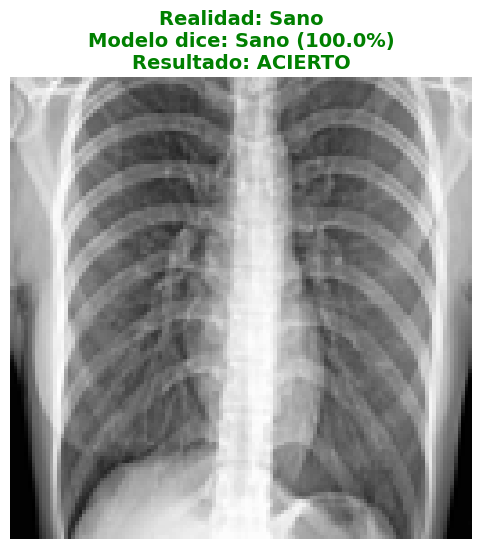

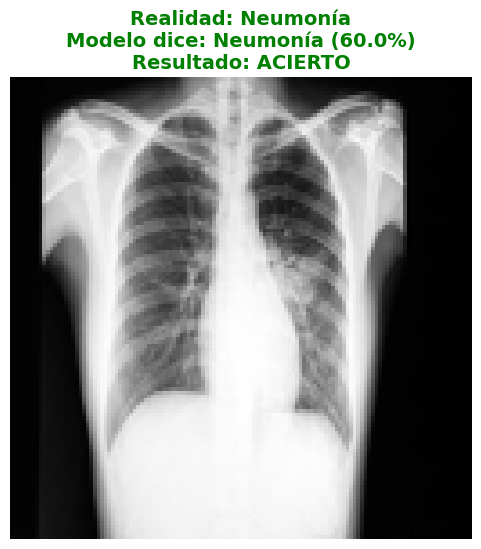

In [ ]:
diagnosticar_imagen_urlknn("https://amismedical.com/wp-content/uploads/2025/01/Normal-Chest-X-Ray-2.png", knn, etiqueta_real=0)

diagnosticar_imagen_urlknn("https://www.itnonline.com/sites/default/files/styles/content_large/public/GettyImages-1140483100.jpg?itok=H5HOE8kn", knn, etiqueta_real=1)

Generando reporte de validación con el modelo KNN...
Informe generado con exito. Descarga el archivo 'Reporte_Prueba_Externa.html'.



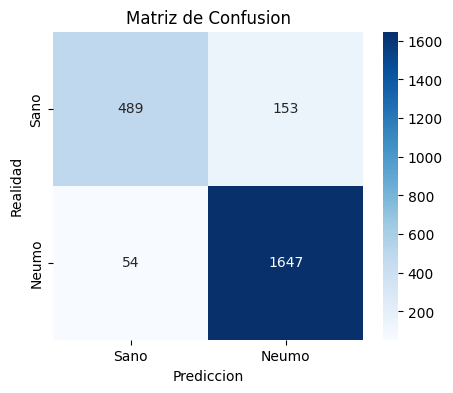
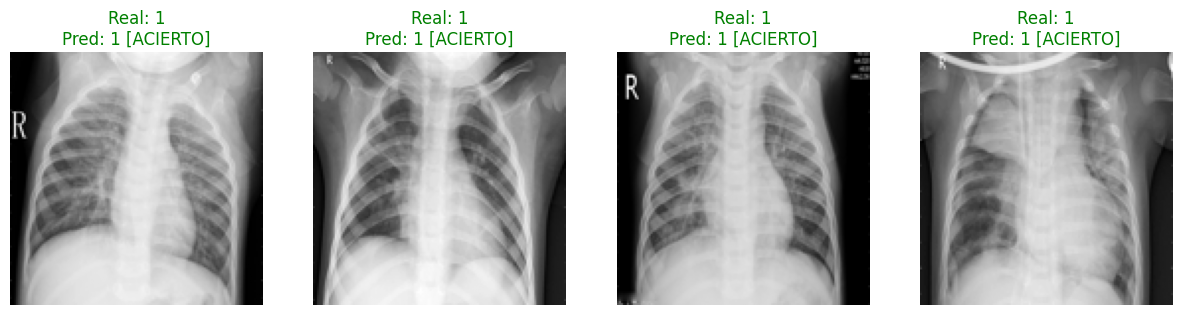

In [ ]:
import os
import glob
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from PIL import Image
import base64
from io import BytesIO
from IPython.display import HTML, display

# 1. Configuración
Nombre_Validacion = "Set de Test (20%)" # Corrección del % para Knn

# 2. Funciones auxiliares
def fig_to_base64(fig):
    buf = BytesIO()
    fig.savefig(buf, format='png', bbox_inches='tight', dpi=100)
    return base64.b64encode(buf.getvalue()).decode('utf-8')

print("Generando reporte de validación con el modelo KNN...")

# --- Adaptations for KNN model and existing X_test, y_test ---

y_pred = knn_eval.predict(X_test)
y_real = y_test

# 5. Cálculos Estadísticos
acertados = np.sum(y_real == y_pred)
errados = len(y_real) - acertados
accuracy = (acertados / len(y_real)) * 100

# ------------------------------------------------------------

# 6. GENERAR GRÁFICOS PARA EL HTML
# A. Matriz de Confusión
cm = confusion_matrix(y_real, y_pred)
fig_cm, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Sano', 'Neumo'], yticklabels=['Sano', 'Neumo'])
plt.title("Matriz de Confusion")
plt.xlabel("Prediccion")
plt.ylabel("Realidad")
img_cm = fig_to_base64(fig_cm)
plt.close(fig_cm)

# B. 4 Resultados Aleatorios
indices_azar = random.sample(range(len(X_test)), min(4, len(X_test)))
fig_azar, axes = plt.subplots(1, len(indices_azar), figsize=(15, 4))

if len(indices_azar) == 1:
    axes = [axes]

for i, idx in enumerate(indices_azar):

    axes[i].imshow(X_test[idx].reshape(128, 128), cmap='gray')

    color = 'green' if y_real.iloc[idx] == y_pred[idx] else 'red'
    res_texto = "[ACIERTO]" if y_real.iloc[idx] == y_pred[idx] else "[FALLO]"

    axes[i].set_title(f"Real: {y_real.iloc[idx]}\nPred: {y_pred[idx]} {res_texto}", color=color)
    axes[i].axis('off')

img_azar = fig_to_base64(fig_azar)
plt.close(fig_azar)

# 7. Construir el HTML
html_reporte = f"""
<!DOCTYPE html>
<html>
<head>
    <meta charset="UTF-8">
    <title>Reporte de Validacion Interna</title>
    <style>
        body {{ font-family: 'Segoe UI', sans-serif; margin: 40px; background-color: #f4f7f6; }}
        .header {{ background-color: #2c3e50; color: white; padding: 30px; text-align: center; border-radius: 10px; }}
        .stats-container {{ display: flex; justify-content: space-around; margin: 20px 0; }}
        .stat-box {{ background: white; padding: 20px; border-radius: 8px; box-shadow: 0 2px 5px rgba(0,0,0,0.1); text-align: center; width: 22%; }}
        .stat-val {{ font-size: 24px; font-weight: bold; color: #2980b9; }}
        .section {{ background: white; padding: 20px; border-radius: 10px; margin-bottom: 20px; box-shadow: 0 2px 5px rgba(0,0,0,0.1); }}
        h2 {{ color: #2c3e50; border-left: 5px solid #2980b9; padding-left: 10px; }}
        .img-main {{ display: block; margin: 0 auto; max-width: 100%; border-radius: 5px; }}
        .grid-img {{ width: 100%; }}
    </style>
</head>
<body>
    <div class="header">
        <h1>Reporte de Validacion: Modelo de Neumonia</h1>
        <p>Evaluacion sobre: <b>{Nombre_Validacion}</b></p>
    </div>

    <div class="stats-container">
        <div class="stat-box"><div>Total Imagenes</div><div class="stat-val">{len(y_real)}</div></div>
        <div class="stat-box"><div>Aciertos</div><div class="stat-val">{acertados}</div></div>
        <div class="stat-box"><div>Errores</div><div class="stat-val">{errados}</div></div>
        <div class="stat-box"><div>Precision Final</div><div class="stat-val">{accuracy:.2f}%</div></div>
    </div>

    <div class="section">
        <h2>1. Analisis de Confusion</h2>
        <p>Este grafico muestra la distribucion de aciertos y errores del modelo (falsos positivos vs falsos negativos).</p>
        <img src="data:image/png;base64,{img_cm}" class="img-main" style="width:400px;">
    </div>

    <div class="section">
        <h2>2. Muestra Aleatoria de Resultados</h2>
        <p>Visualizacion de 4 casos tomados al azar del lote de prueba.</p>
        <img src="data:image/png;base64,{img_azar}" class="grid-img"> <!-- Corrected base664 to base64 here -->
    </div>

    <div class="section">
        <h2>3. Conclusion del Test</h2>
        <p>El modelo presenta un desempeno de <b>{accuracy:.2f}%</b> en datos no vistos durante el entrenamiento.</p>
    </div>
</body>
</html>
"""

# 8. Guardar archivo
with open("Reporte_Prueba_Externa.html", "w", encoding="utf-8") as f:
    f.write(html_reporte)

print("Informe generado con exito. Descarga el archivo 'Reporte_Prueba_Externa.html'.")

display(HTML(html_reporte))